# Computational Imaging Project — Super Resolution on FFHQ 256×256

**Individual project version**

Methods implemented:
1. **Baseline:** Bicubic interpolation
2. **Variational method:** Total Variation denoising/reconstruction
3. **End-to-end method:** UNet trained for super-resolution reconstruction

Project requirements covered: FFHQ 256×256, super-resolution, SR factors ×2/×4, noise levels 0.005/0.01, PSNR/SSIM, visual comparisons and plots.

The degraded input is generated once in a consistent way and reused by all methods.

## 0. Colab setup
Run this first. For UNet training, use **Runtime → Change runtime type → GPU**.

In [1]:
!pip -q install datasets huggingface_hub scikit-image opencv-python tqdm pandas matplotlib

## 1. Imports and global configuration

In [2]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.restoration import denoise_tv_chambolle

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    from datasets import load_dataset
except Exception:
    load_dataset = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMAGE_SIZE = 256
MAX_IMAGES = 4000
SR_FACTORS = [2, 4]
NOISE_LEVELS = [0.005, 0.01]

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

ROOT_DIR = Path("/content/computational_imaging_project")
DATA_DIR = ROOT_DIR / "data"
FIGURES_DIR = ROOT_DIR / "figures"
RESULTS_DIR = ROOT_DIR / "results"
MODELS_DIR = ROOT_DIR / "models"

for p in [DATA_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project folder:", ROOT_DIR)

Device: cuda
Project folder: /content/computational_imaging_project


## 2. Utility functions
Keep this cell before every experiment.

In [3]:
def to_float01(img):
    """Convert an image-like object to float32 in [0, 1]."""
    if isinstance(img, Image.Image):
        img = img.convert("RGB")
        arr = np.array(img)
    else:
        arr = np.array(img)
        if arr.ndim == 2:
            arr = np.stack([arr] * 3, axis=-1)
        if arr.shape[-1] == 4:
            arr = arr[..., :3]

    arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr /= 255.0
    return np.clip(arr, 0.0, 1.0)


def resize_rgb(img, size=IMAGE_SIZE):
    """Resize image to size x size using PIL."""
    arr = to_float01(img)
    pil = Image.fromarray((arr * 255).astype(np.uint8))
    pil = pil.resize((size, size), Image.BICUBIC)
    return to_float01(pil)


def degrade_image(gt, scale, noise_level, return_lr=False):
    """
    Common degradation model:
    ground truth -> downsampling -> bicubic upsampling -> additive Gaussian noise.
    """
    gt = resize_rgb(gt, IMAGE_SIZE)
    h, w = gt.shape[:2]
    lr_size = (w // scale, h // scale)

    lr = cv2.resize(gt, lr_size, interpolation=cv2.INTER_CUBIC)
    up = cv2.resize(lr, (w, h), interpolation=cv2.INTER_CUBIC)

    if noise_level > 0:
        noise = np.random.normal(0.0, noise_level, size=up.shape).astype(np.float32)
        degraded = up + noise
    else:
        degraded = up

    degraded = np.clip(degraded, 0.0, 1.0).astype(np.float32)
    lr = np.clip(lr, 0.0, 1.0).astype(np.float32)
    return (degraded, lr) if return_lr else degraded


def compute_psnr(gt, recon):
    gt = np.clip(gt, 0, 1).astype(np.float32)
    recon = np.clip(recon, 0, 1).astype(np.float32)
    return peak_signal_noise_ratio(gt, recon, data_range=1.0)


def compute_ssim(gt, recon):
    gt = np.clip(gt, 0, 1).astype(np.float32)
    recon = np.clip(recon, 0, 1).astype(np.float32)
    return structural_similarity(gt, recon, channel_axis=-1, data_range=1.0)


def plot_images(images, titles=None, figsize=(16, 4), save_path=None):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(1, n, i + 1)
        plt.imshow(np.clip(img, 0, 1))
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i])
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def chw_to_hwc(x):
    return np.transpose(x, (1, 2, 0))


def hwc_to_chw(x):
    return np.transpose(x, (2, 0, 1))

## 3. Load FFHQ 256×256 from Hugging Face
Dataset: `bitmind/ffhq-256`.

In [4]:
def extract_image_from_sample(sample):
    candidate_keys = ["image", "jpg", "png", "file", "path"]
    for key in candidate_keys:
        if key in sample:
            value = sample[key]
            if isinstance(value, Image.Image):
                return value
            if isinstance(value, str) and os.path.exists(value):
                return Image.open(value).convert("RGB")
    for value in sample.values():
        if isinstance(value, Image.Image):
            return value
    raise ValueError(f"No image-like field found. Available keys: {list(sample.keys())}")


def load_ffhq_from_huggingface(max_images=MAX_IMAGES):
    if load_dataset is None:
        raise RuntimeError("datasets is not available. Run the installation cell first.")
    ds = load_dataset("bitmind/ffhq-256", split="train", streaming=False)
    n = min(max_images, len(ds))
    images = []
    for i in tqdm(range(n), desc="Loading FFHQ images"):
        sample = ds[i]
        img = extract_image_from_sample(sample)
        images.append(resize_rgb(img, IMAGE_SIZE))
    return images

all_images = load_ffhq_from_huggingface(MAX_IMAGES)
print("Loaded images:", len(all_images))
print("Image shape:", all_images[0].shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/288 [00:00<?, ?B/s]

data/train-00000-of-00016.parquet:   0%|          | 0.00/476M [00:00<?, ?B/s]

data/train-00001-of-00016.parquet:   0%|          | 0.00/478M [00:00<?, ?B/s]

data/train-00002-of-00016.parquet:   0%|          | 0.00/479M [00:00<?, ?B/s]

...

data/train-00014-of-00016.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

data/train-00015-of-00016.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Loading FFHQ images:   0%|          | 0/4000 [00:00<?, ?it/s]

Loaded images: 4000
Image shape: (256, 256, 3)


### Optional fallback: load from local folder
Run only if the Hugging Face loading cell fails.

In [5]:
# LOCAL_DATASET_DIR = Path("/content/ffhq_256")
#
# def load_images_from_folder(folder, max_images=MAX_IMAGES):
#     image_paths = []
#     for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp"]:
#         image_paths.extend(sorted(folder.glob(ext)))
#     image_paths = image_paths[:max_images]
#     images = []
#     for path in tqdm(image_paths, desc="Loading local images"):
#         try:
#             img = Image.open(path).convert("RGB")
#             images.append(resize_rgb(img, IMAGE_SIZE))
#         except Exception as e:
#             print("Skipping", path, e)
#     return images
#
# all_images = load_images_from_folder(LOCAL_DATASET_DIR, MAX_IMAGES)
# print("Loaded images:", len(all_images))

## 4. Train / validation / test split

Total: 4000
Train: 3200
Validation: 400
Test: 400


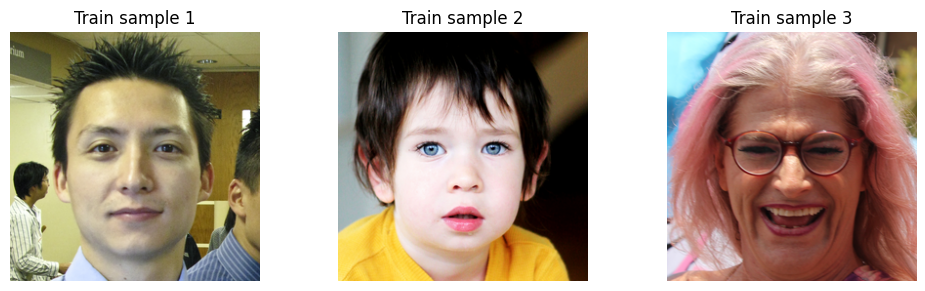

In [6]:
assert "all_images" in globals() and len(all_images) > 0, "Load the dataset before running this cell."

indices = np.arange(len(all_images))
np.random.shuffle(indices)

n_total = len(indices)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

train_images = [all_images[i] for i in train_idx]
val_images = [all_images[i] for i in val_idx]
test_images = [all_images[i] for i in test_idx]

print(f"Total: {len(all_images)}")
print(f"Train: {len(train_images)}")
print(f"Validation: {len(val_images)}")
print(f"Test: {len(test_images)}")

plot_images([train_images[0], train_images[1], train_images[2]],
            ["Train sample 1", "Train sample 2", "Train sample 3"],
            figsize=(10, 3),
            save_path=FIGURES_DIR / "dataset_samples.png")

## 5. Visualize the degradation model

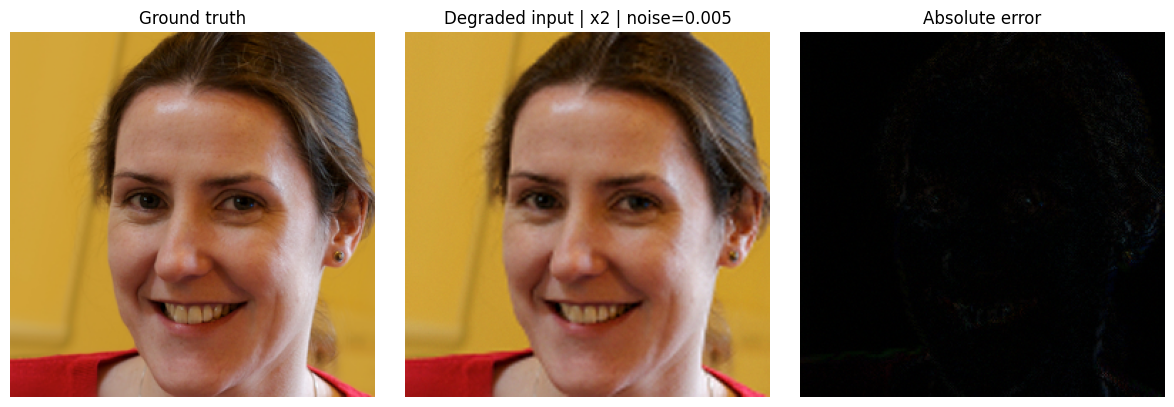

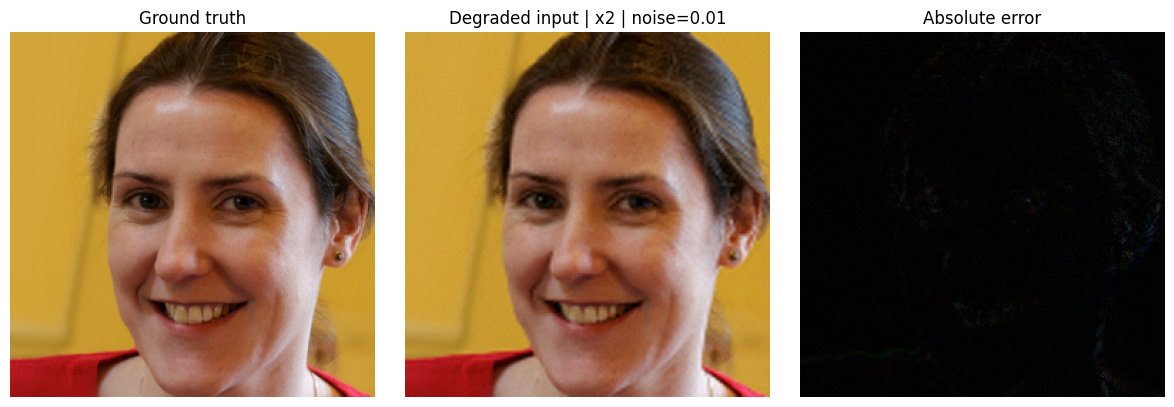

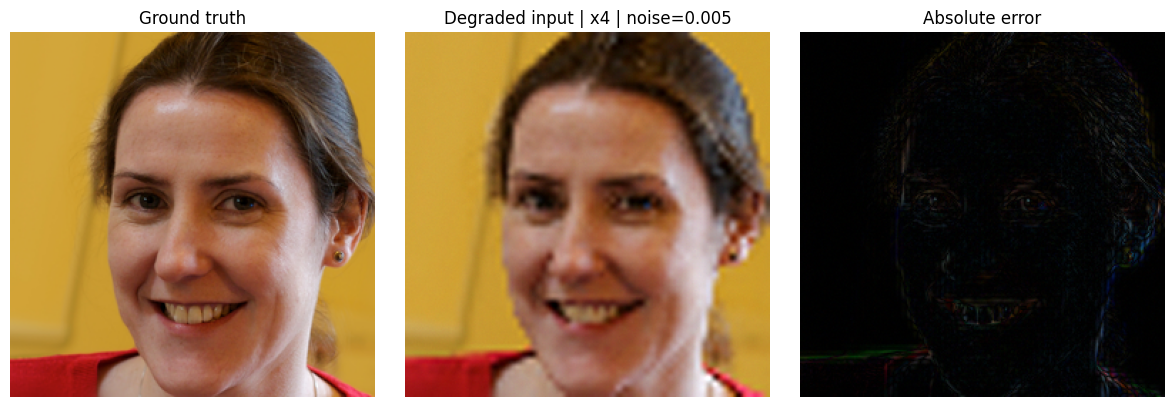

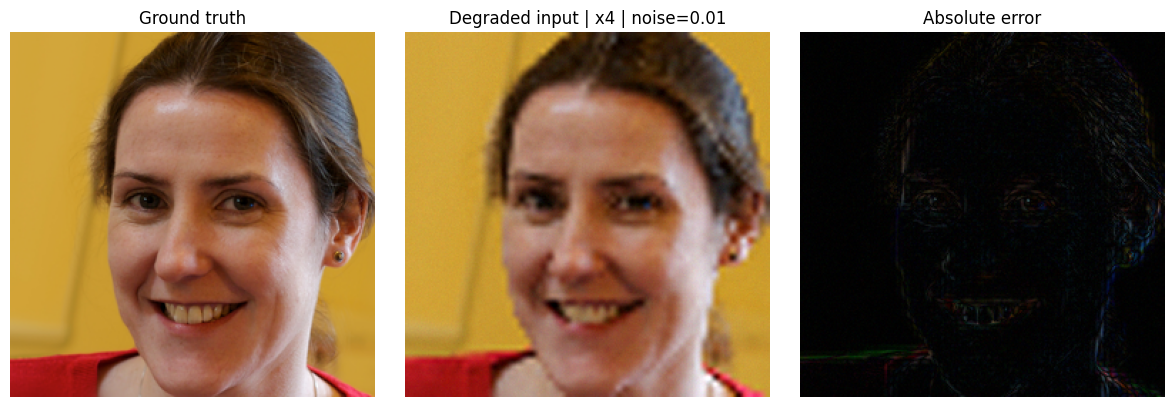

In [7]:
sample_gt = test_images[0]

for scale in SR_FACTORS:
    for noise_level in NOISE_LEVELS:
        degraded = degrade_image(
            sample_gt,
            scale=scale,
            noise_level=noise_level
        )

        plot_images(
            [
                sample_gt,
                degraded,
                np.abs(sample_gt - degraded)
            ],
            [
                "Ground truth",
                f"Degraded input | x{scale} | noise={noise_level}",
                "Absolute error"
            ],
            figsize=(12, 4),
            save_path=FIGURES_DIR / f"degradation_x{scale}_noise{noise_level}.png"
        )

## 6. Baseline: bicubic interpolation

In [8]:
def bicubic_reconstruction(degraded_input):
    # degrade_image already performs bicubic upsampling; baseline returns that input.
    return np.clip(degraded_input, 0.0, 1.0).astype(np.float32)

## 7. Variational method: Total Variation

In [9]:
def tv_super_resolution(degraded_input, weight=0.05):
    recon = denoise_tv_chambolle(degraded_input, weight=weight, channel_axis=-1)
    return np.clip(recon, 0.0, 1.0).astype(np.float32)

## 8. Evaluation functions

In [10]:
def evaluate_method(method_name, reconstruction_fn, images, scale, noise_level, max_images=None):
    if max_images is not None:
        images = images[:max_images]

    psnr_values = []
    ssim_values = []

    for gt in tqdm(images, desc=f"{method_name} | x{scale} | noise={noise_level}"):
        degraded = degrade_image(gt, scale=scale, noise_level=noise_level)
        recon = reconstruction_fn(degraded)
        psnr_values.append(compute_psnr(gt, recon))
        ssim_values.append(compute_ssim(gt, recon))

    return {
        "method": method_name,
        "scale": scale,
        "noise_level": noise_level,
        "PSNR": float(np.mean(psnr_values)),
        "SSIM": float(np.mean(ssim_values)),
    }


def evaluate_grid(method_name, reconstruction_fn, images, max_images=None):
    rows = []
    for scale in SR_FACTORS:
        for noise_level in NOISE_LEVELS:
            rows.append(evaluate_method(method_name, reconstruction_fn, images, scale, noise_level, max_images))
    return pd.DataFrame(rows)

## 9. Baseline evaluation

In [11]:
EVAL_IMAGES_FAST = 80  # set to None for full test set

bicubic_summary = evaluate_grid("Bicubic", bicubic_reconstruction, test_images, max_images=EVAL_IMAGES_FAST)
bicubic_summary

Bicubic | x2 | noise=0.005:   0%|          | 0/80 [00:00<?, ?it/s]

Bicubic | x2 | noise=0.01:   0%|          | 0/80 [00:00<?, ?it/s]

Bicubic | x4 | noise=0.005:   0%|          | 0/80 [00:00<?, ?it/s]

Bicubic | x4 | noise=0.01:   0%|          | 0/80 [00:00<?, ?it/s]

,method,scale,noise_level,PSNR,SSIM
0,Bicubic,2,0.005,32.171025,0.927407
1,Bicubic,2,0.010,31.606319,0.899220
2,Bicubic,4,0.005,26.262097,0.799796
3,Bicubic,4,0.010,26.110157,0.774119


## 10. TV parameter search
The TV regularization parameter is selected empirically by grid search.

In [12]:
tv_weights = [0.005, 0.01, 0.02, 0.05, 0.08, 0.12]
TV_SEARCH_IMAGES = 50

tv_search_rows = []
for weight in tv_weights:
    for scale in SR_FACTORS:
        for noise_level in NOISE_LEVELS:
            row = evaluate_method(
                method_name=f"TV_weight_{weight}",
                reconstruction_fn=lambda img, w=weight: tv_super_resolution(img, weight=w),
                images=test_images,
                scale=scale,
                noise_level=noise_level,
                max_images=TV_SEARCH_IMAGES,
            )
            row["weight"] = weight
            tv_search_rows.append(row)

tv_search_df = pd.DataFrame(tv_search_rows)
tv_search_df.sort_values(["scale", "noise_level", "PSNR"], ascending=[True, True, False])

TV_weight_0.005 | x2 | noise=0.005:   0%|          | 0/50 [00:00<?, ?it/s]

TV_weight_0.005 | x2 | noise=0.01:   0%|          | 0/50 [00:00<?, ?it/s]

TV_weight_0.005 | x4 | noise=0.005:   0%|          | 0/50 [00:00<?, ?it/s]

TV_weight_0.005 | x4 | noise=0.01:   0%|          | 0/50 [00:00<?, ?it/s]

TV_weight_0.01 | x2 | noise=0.005:   0%|          | 0/50 [00:00<?, ?it/s]

...

TV_weight_0.12 | x2 | noise=0.005:   0%|          | 0/50 [00:00<?, ?it/s]

TV_weight_0.12 | x2 | noise=0.01:   0%|          | 0/50 [00:00<?, ?it/s]

TV_weight_0.12 | x4 | noise=0.005:   0%|          | 0/50 [00:00<?, ?it/s]

TV_weight_0.12 | x4 | noise=0.01:   0%|          | 0/50 [00:00<?, ?it/s]

,method,scale,noise_level,PSNR,SSIM,weight
0,TV_weight_0.005,2,0.005,32.680946,0.934056,0.005
4,TV_weight_0.01,2,0.005,32.625756,0.929489,0.010
8,TV_weight_0.02,2,0.005,32.317934,0.917686,0.020
12,TV_weight_0.05,2,0.005,31.252994,0.889395,0.050
16,TV_weight_0.08,2,0.005,30.291285,0.865329,0.080
20,TV_weight_0.12,2,0.005,29.252005,0.838568,0.120
5,TV_weight_0.01,2,0.010,32.462780,0.925088,0.010
1,TV_weight_0.005,2,0.010,32.410998,0.925471,0.005
9,TV_weight_0.02,2,0.010,32.244249,0.915968,0.020
13,TV_weight_0.05,2,0.010,31.215724,0.887703,0.050


In [13]:
best_tv = (tv_search_df
    .sort_values("PSNR", ascending=False)
    .groupby(["scale", "noise_level"], as_index=False)
    .first()
    .sort_values(["scale", "noise_level"])
    .reset_index(drop=True))

best_tv

,scale,noise_level,method,PSNR,SSIM,weight
0,2,0.005,TV_weight_0.005,32.680946,0.934056,0.005
1,2,0.010,TV_weight_0.01,32.462780,0.925088,0.010
2,4,0.005,TV_weight_0.05,26.921526,0.808027,0.050
3,4,0.010,TV_weight_0.05,26.912307,0.807419,0.050


## 11. Evaluate TV with selected weights

In [14]:
def get_best_tv_weight(scale, noise_level):
    row = best_tv[(best_tv["scale"] == scale) & (best_tv["noise_level"] == noise_level)]
    if len(row) == 0:
        return 0.05
    return float(row.iloc[0]["weight"])


tv_summary_rows = []
for scale in SR_FACTORS:
    for noise_level in NOISE_LEVELS:
        weight = get_best_tv_weight(scale, noise_level)
        row = evaluate_method(
            method_name="TV",
            reconstruction_fn=lambda img, w=weight: tv_super_resolution(img, weight=w),
            images=test_images,
            scale=scale,
            noise_level=noise_level,
            max_images=EVAL_IMAGES_FAST,
        )
        row["weight"] = weight
        tv_summary_rows.append(row)

tv_summary = pd.DataFrame(tv_summary_rows)
tv_summary

TV | x2 | noise=0.005:   0%|          | 0/80 [00:00<?, ?it/s]

TV | x2 | noise=0.01:   0%|          | 0/80 [00:00<?, ?it/s]

TV | x4 | noise=0.005:   0%|          | 0/80 [00:00<?, ?it/s]

TV | x4 | noise=0.01:   0%|          | 0/80 [00:00<?, ?it/s]

,method,scale,noise_level,PSNR,SSIM,weight
0,TV,2,0.005,32.371004,0.932525,0.005
1,TV,2,0.010,32.167921,0.923525,0.010
2,TV,4,0.005,26.568661,0.802166,0.050
3,TV,4,0.010,26.558952,0.801161,0.050


## 12. UNet end-to-end method
Input: degraded bicubic-upsampled RGB image. Output: clean 256×256 RGB image.

In [15]:
class SRDataset(Dataset):
    def __init__(self, images, scale=2, noise_level=0.005):
        self.images = images
        self.scale = scale
        self.noise_level = noise_level

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        gt = self.images[idx]
        degraded = degrade_image(gt, scale=self.scale, noise_level=self.noise_level)
        x = torch.from_numpy(hwc_to_chw(degraded)).float()
        y = torch.from_numpy(hwc_to_chw(gt)).float()
        return x, y


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 4, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return torch.clamp(x + self.out(d1), 0.0, 1.0)

## 13. Train UNet models
For quick testing: 800 training images and 3 epochs. Increase for final results if Colab time allows.

In [16]:
def train_unet_for_config(scale, noise_level, epochs=3, batch_size=8, lr=1e-3, train_limit=800, val_limit=100):
    train_subset = train_images[:train_limit] if train_limit is not None else train_images
    val_subset = val_images[:val_limit] if val_limit is not None else val_images

    train_ds = SRDataset(train_subset, scale=scale, noise_level=noise_level)
    val_ds = SRDataset(val_subset, scale=scale, noise_level=noise_level)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model = SmallUNet(base=32).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.L1Loss()
    history = []
    best_val = float("inf")
    model_path = MODELS_DIR / f"unet_x{scale}_noise{noise_level}.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for x, y in tqdm(train_loader, desc=f"Train UNet x{scale}, noise={noise_level}, epoch {epoch}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                val_losses.append(loss_fn(pred, y).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        print(f"Epoch {epoch}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), model_path)

    model.load_state_dict(torch.load(model_path, map_location=device))
    return model, pd.DataFrame(history), model_path

In [17]:
TRAIN_IMAGES_FAST = 800
VAL_IMAGES_FAST = 100
EPOCHS = 3
BATCH_SIZE = 8
LEARNING_RATE = 1e-3

trained_models = {}
training_histories = {}

for scale in SR_FACTORS:
    for noise_level in NOISE_LEVELS:
        model, history, path = train_unet_for_config(
            scale=scale,
            noise_level=noise_level,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
            train_limit=TRAIN_IMAGES_FAST,
            val_limit=VAL_IMAGES_FAST,
        )
        trained_models[(scale, noise_level)] = model
        training_histories[(scale, noise_level)] = history
        print("Saved:", path)

Train UNet x2, noise=0.005, epoch 1/3:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: train_loss=0.01784, val_loss=0.01431


Train UNet x2, noise=0.005, epoch 2/3:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2: train_loss=0.01436, val_loss=0.01414


Train UNet x2, noise=0.005, epoch 3/3:   0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch 1: train_loss=0.03078, val_loss=0.02774


Train UNet x4, noise=0.01, epoch 2/3:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2: train_loss=0.02769, val_loss=0.02736


Train UNet x4, noise=0.01, epoch 3/3:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 3: train_loss=0.02727, val_loss=0.02689
Saved: /content/computational_imaging_project/models/unet_x4_noise0.01.pt


## 14. UNet reconstruction and evaluation

In [18]:
def unet_reconstruct(model, degraded_input):
    model.eval()
    x = torch.from_numpy(hwc_to_chw(degraded_input)).float().unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).squeeze(0).cpu().numpy()
    return np.clip(chw_to_hwc(pred), 0.0, 1.0).astype(np.float32)


unet_summary_rows = []
for scale in SR_FACTORS:
    for noise_level in NOISE_LEVELS:
        model = trained_models[(scale, noise_level)]
        row = evaluate_method(
            method_name="UNet",
            reconstruction_fn=lambda img, m=model: unet_reconstruct(m, img),
            images=test_images,
            scale=scale,
            noise_level=noise_level,
            max_images=EVAL_IMAGES_FAST,
        )
        unet_summary_rows.append(row)

unet_summary = pd.DataFrame(unet_summary_rows)
unet_summary

UNet | x2 | noise=0.005:   0%|          | 0/80 [00:00<?, ?it/s]

UNet | x2 | noise=0.01:   0%|          | 0/80 [00:00<?, ?it/s]

UNet | x4 | noise=0.005:   0%|          | 0/80 [00:00<?, ?it/s]

UNet | x4 | noise=0.01:   0%|          | 0/80 [00:00<?, ?it/s]

,method,scale,noise_level,PSNR,SSIM
0,UNet,2,0.005,32.187161,0.927365
1,UNet,2,0.010,31.652624,0.900733
2,UNet,4,0.005,26.486289,0.801842
3,UNet,4,0.010,26.357364,0.778325


## 15. Final quantitative comparison

In [19]:
summary = pd.concat(
    [bicubic_summary, tv_summary.drop(columns=["weight"], errors="ignore"), unet_summary],
    ignore_index=True
)
summary = summary.sort_values(["scale", "noise_level", "method"]).reset_index(drop=True)
summary.to_csv(RESULTS_DIR / "summary_metrics.csv", index=False)
summary

,method,scale,noise_level,PSNR,SSIM
0,Bicubic,2,0.005,32.171025,0.927407
1,TV,2,0.005,32.371004,0.932525
2,UNet,2,0.005,32.187161,0.927365
3,Bicubic,2,0.010,31.606319,0.899220
4,TV,2,0.010,32.167921,0.923525
5,UNet,2,0.010,31.652624,0.900733
6,Bicubic,4,0.005,26.262097,0.799796
7,TV,4,0.005,26.568661,0.802166
8,UNet,4,0.005,26.486289,0.801842
9,Bicubic,4,0.010,26.110157,0.774119


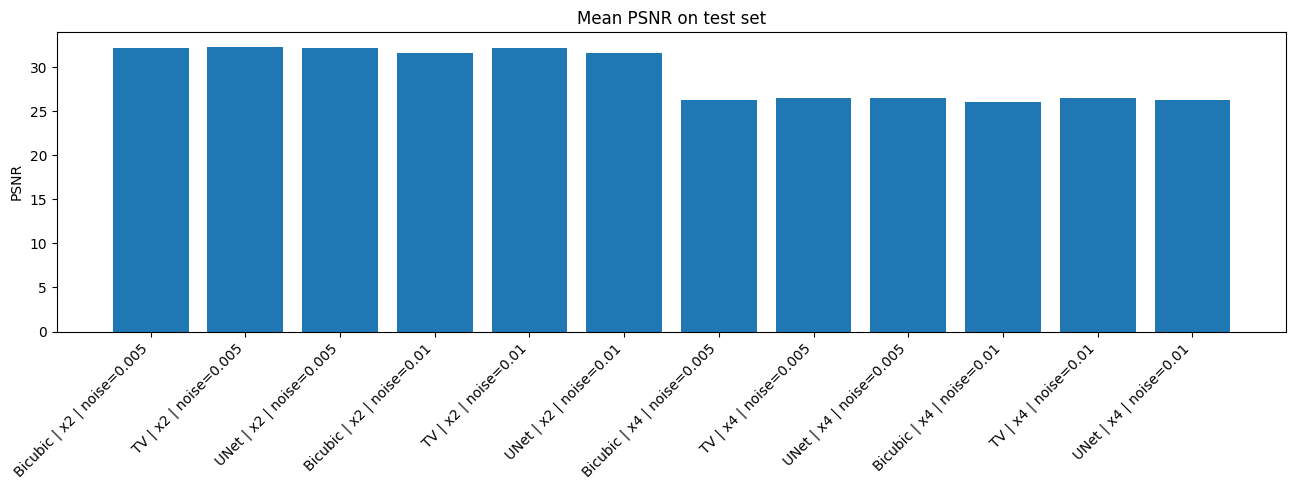

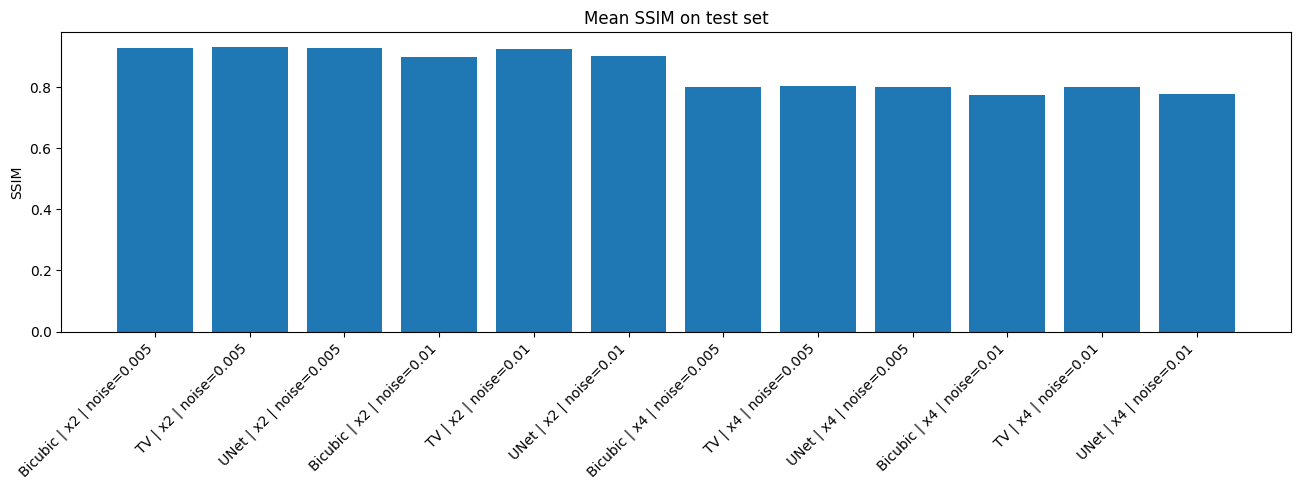

In [20]:
def plot_metric_summary(summary_df, metric="PSNR", save_path=None):
    labels = [f"{r.method} | x{int(r.scale)} | noise={r.noise_level}" for r in summary_df.itertuples()]
    values = [getattr(r, metric) for r in summary_df.itertuples()]
    plt.figure(figsize=(max(10, len(labels) * 1.1), 5))
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(values)), labels, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"Mean {metric} on test set")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

plot_metric_summary(summary, "PSNR", FIGURES_DIR / "psnr_summary.png")
plot_metric_summary(summary, "SSIM", FIGURES_DIR / "ssim_summary.png")

## 16. Visual comparison

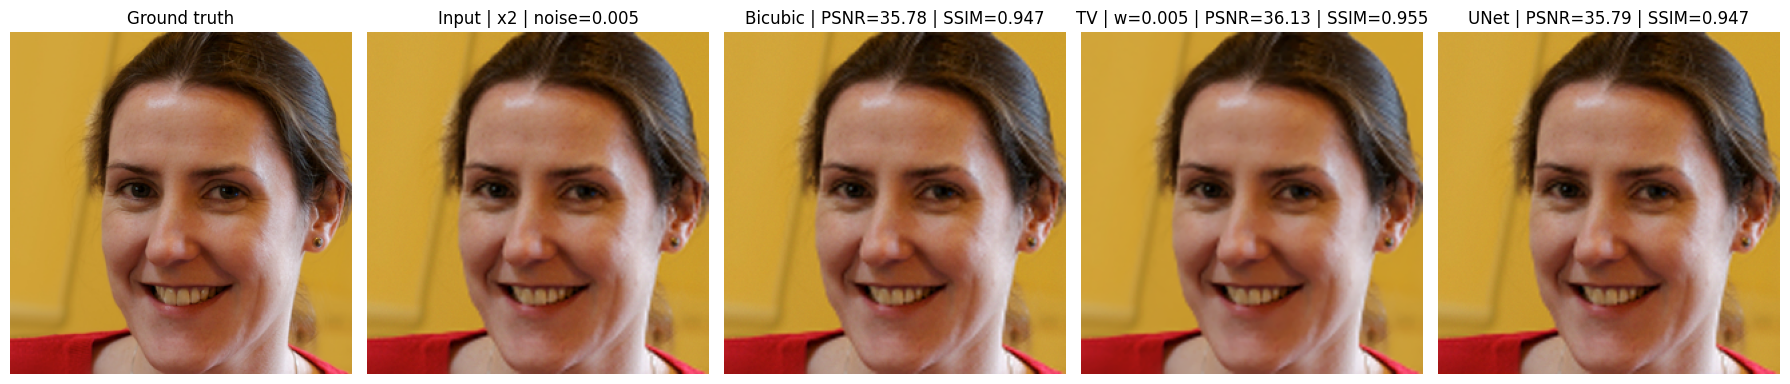

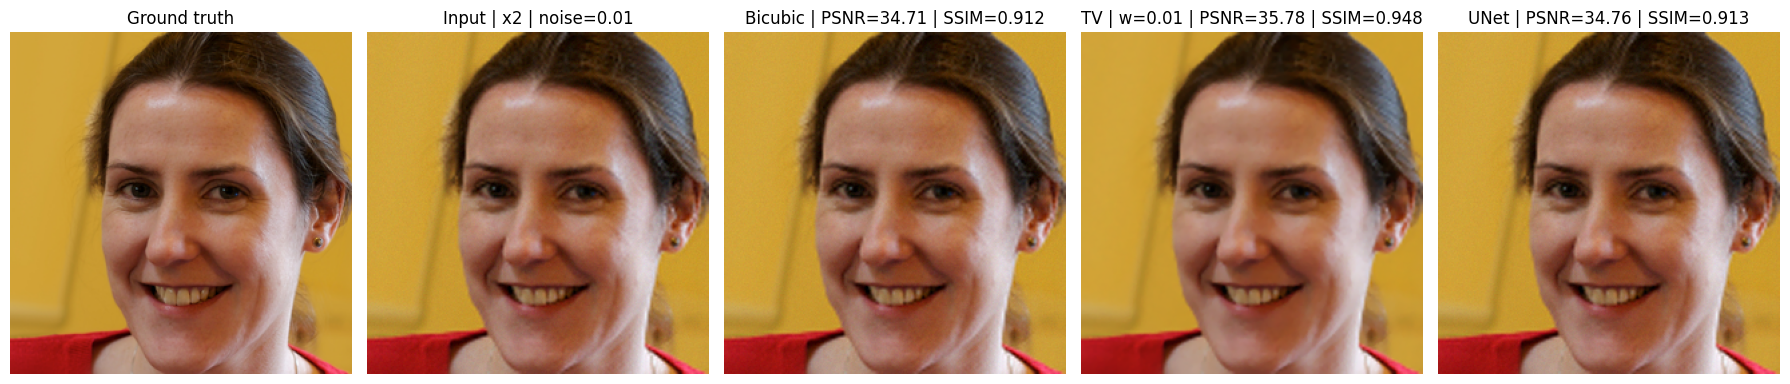

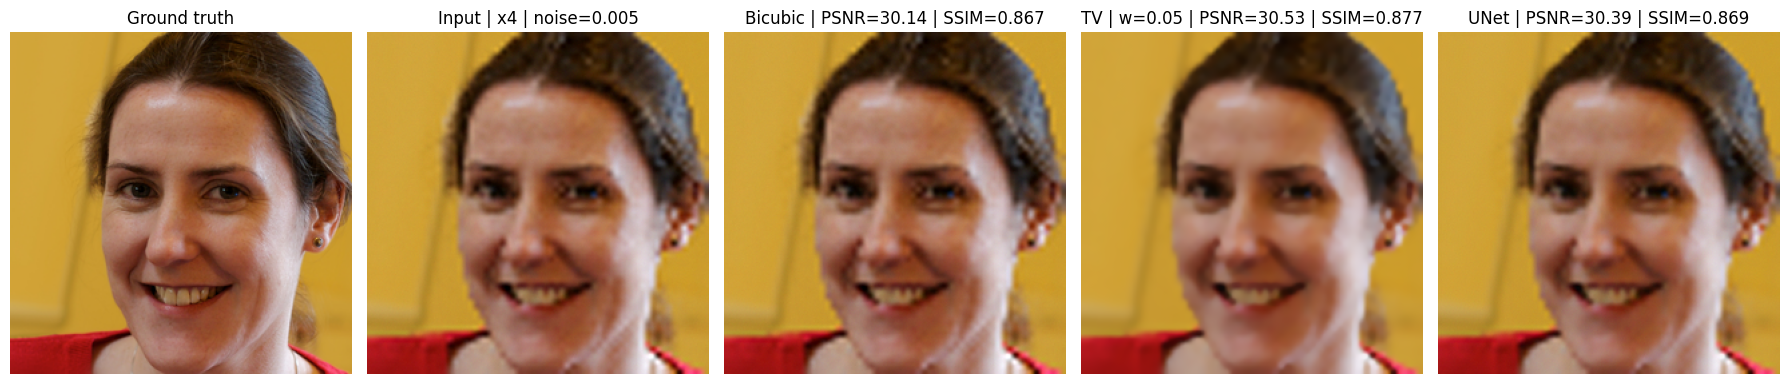

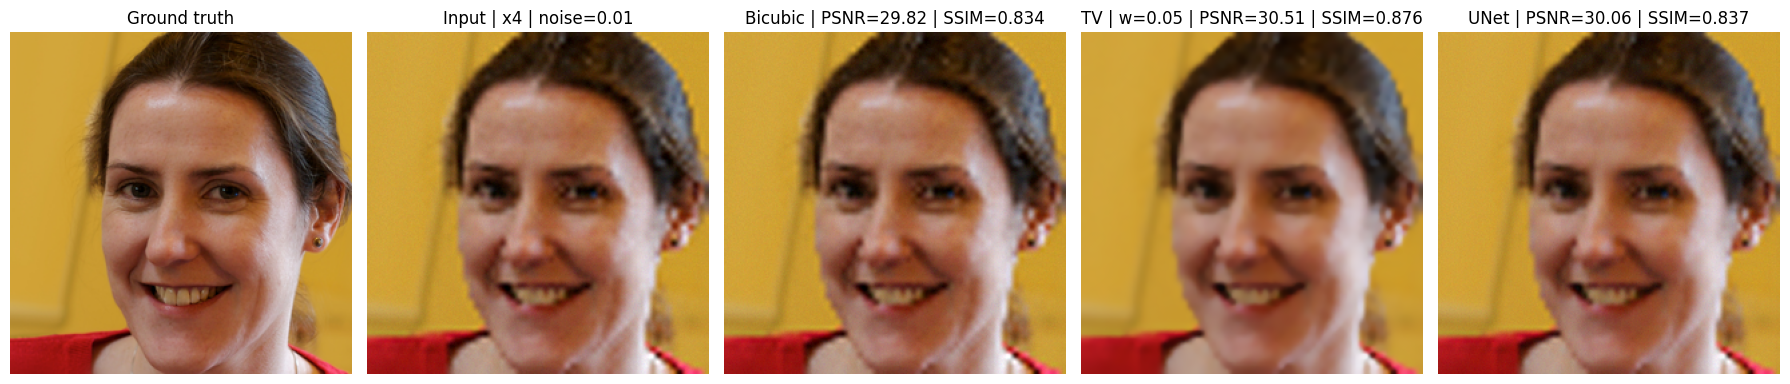

In [21]:
def compare_methods_on_image(image_idx=0, scale=2, noise_level=0.005, save_path=None):
    gt = test_images[image_idx]

    degraded = degrade_image(
        gt,
        scale=scale,
        noise_level=noise_level
    )

    bic = bicubic_reconstruction(degraded)

    tv_w = get_best_tv_weight(scale, noise_level)
    tv = tv_super_resolution(
        degraded,
        weight=tv_w
    )

    model = trained_models.get((scale, noise_level), None)

    if model is not None:
        unet = unet_reconstruct(model, degraded)

        images = [gt, degraded, bic, tv, unet]

        titles = [
            "Ground truth",
            f"Input | x{scale} | noise={noise_level}",
            f"Bicubic | PSNR={compute_psnr(gt, bic):.2f} | SSIM={compute_ssim(gt, bic):.3f}",
            f"TV | w={tv_w} | PSNR={compute_psnr(gt, tv):.2f} | SSIM={compute_ssim(gt, tv):.3f}",
            f"UNet | PSNR={compute_psnr(gt, unet):.2f} | SSIM={compute_ssim(gt, unet):.3f}",
        ]

    else:
        images = [gt, degraded, bic, tv]

        titles = [
            "Ground truth",
            f"Input | x{scale} | noise={noise_level}",
            "Bicubic",
            f"TV | w={tv_w}"
        ]

    plot_images(
        images,
        titles,
        figsize=(18, 4),
        save_path=save_path
    )


for scale in SR_FACTORS:
    for noise_level in NOISE_LEVELS:
        compare_methods_on_image(
            image_idx=0,
            scale=scale,
            noise_level=noise_level,
            save_path=FIGURES_DIR / f"comparison_x{scale}_noise{noise_level}.png"
        )

## 17. Crop and error maps for presentation

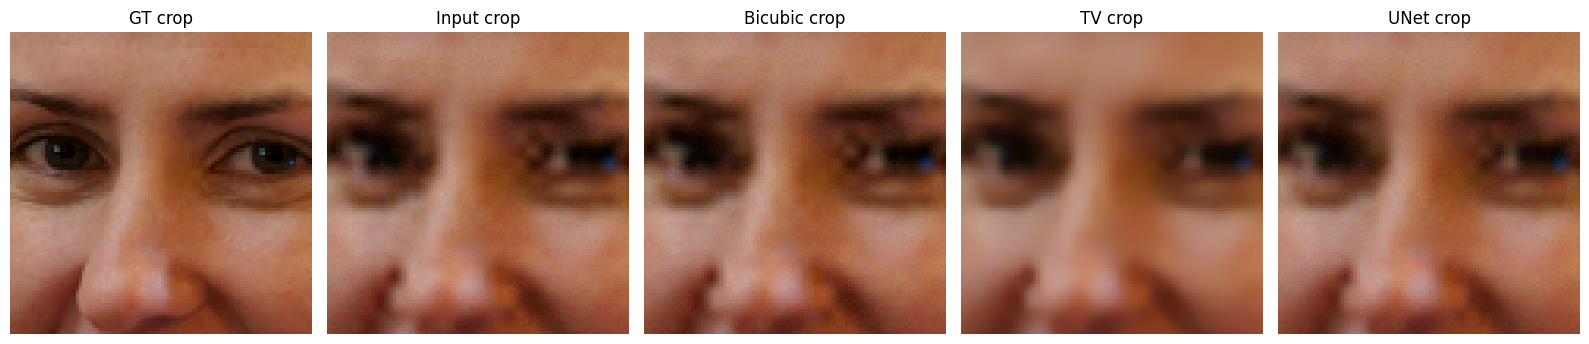

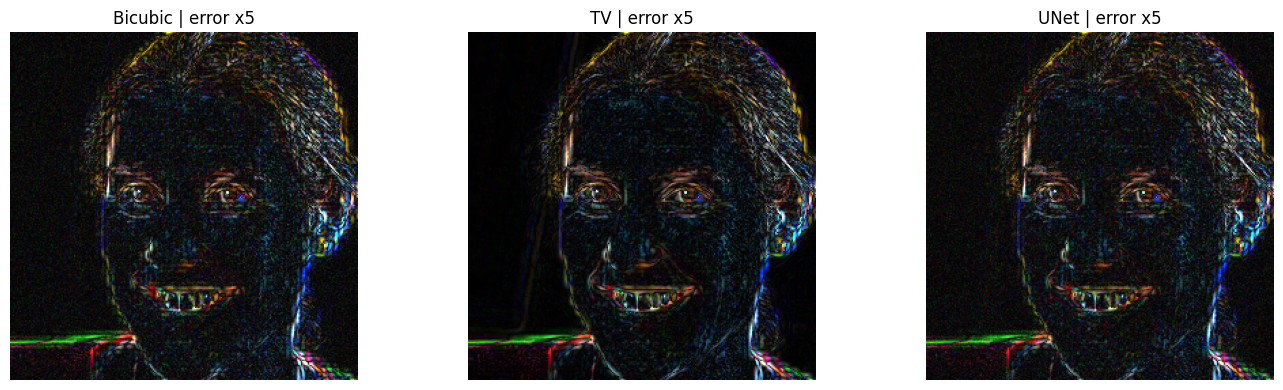

In [22]:
def crop_center(img, crop_size=96):
    h, w = img.shape[:2]
    y0 = h // 2 - crop_size // 2
    x0 = w // 2 - crop_size // 2
    return img[y0:y0 + crop_size, x0:x0 + crop_size]


def compare_crops_and_errors(image_idx=0, scale=4, noise_level=0.01):
    gt = test_images[image_idx]
    degraded = degrade_image(gt, scale=scale, noise_level=noise_level)
    tv_w = get_best_tv_weight(scale, noise_level)

    reconstructions = {
        "Bicubic": bicubic_reconstruction(degraded),
        "TV": tv_super_resolution(degraded, weight=tv_w),
    }
    if (scale, noise_level) in trained_models:
        reconstructions["UNet"] = unet_reconstruct(trained_models[(scale, noise_level)], degraded)

    crop_imgs = [crop_center(gt), crop_center(degraded)]
    crop_titles = ["GT crop", "Input crop"]
    for name, recon in reconstructions.items():
        crop_imgs.append(crop_center(recon))
        crop_titles.append(f"{name} crop")
    plot_images(crop_imgs, crop_titles, figsize=(16, 4), save_path=FIGURES_DIR / f"crops_x{scale}_noise{noise_level}.png")

    error_imgs = []
    error_titles = []
    for name, recon in reconstructions.items():
        err = np.abs(gt - recon)
        error_imgs.append(np.clip(err * 5, 0, 1))
        error_titles.append(f"{name} | error x5")
    plot_images(error_imgs, error_titles, figsize=(14, 4), save_path=FIGURES_DIR / f"errors_x{scale}_noise{noise_level}.png")

compare_crops_and_errors(image_idx=0, scale=4, noise_level=0.01)

## 18. Training curves

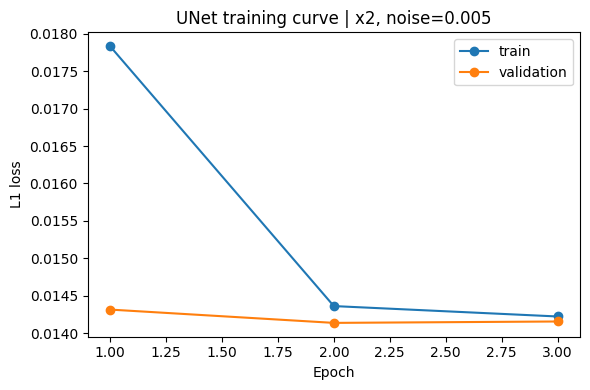

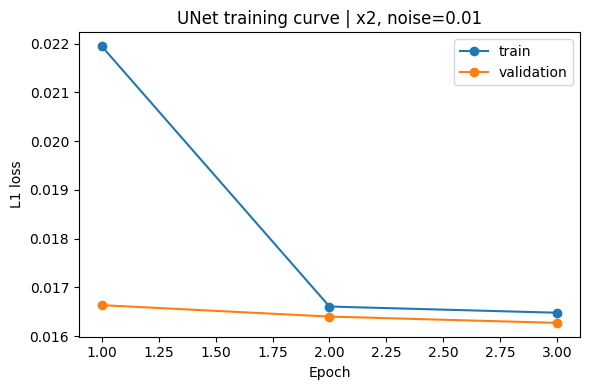

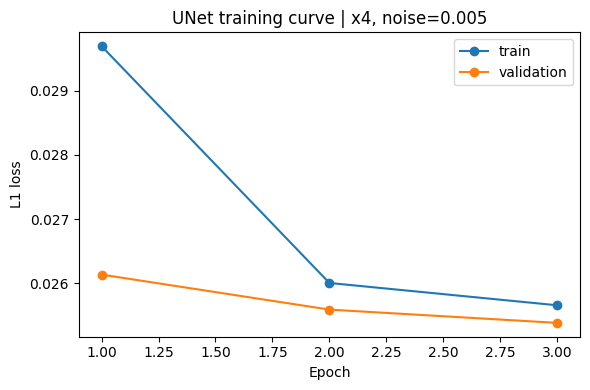

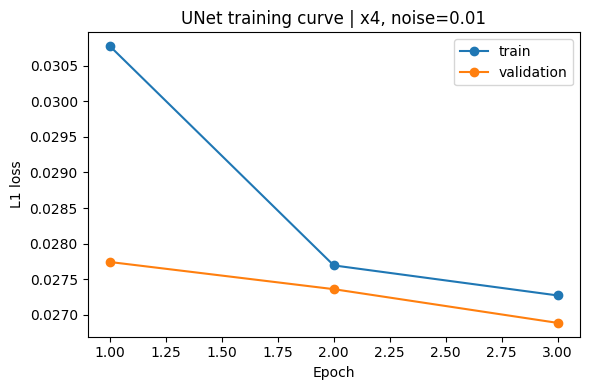

In [23]:
for key, hist in training_histories.items():
    scale, noise_level = key
    plt.figure(figsize=(6, 4))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="train")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("L1 loss")
    plt.title(f"UNet training curve | x{scale}, noise={noise_level}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"training_curve_x{scale}_noise{noise_level}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 19. Notes for the presentation

- The task is an inverse problem: recover a clean high-resolution image from a degraded low-resolution noisy observation.
- Forward degradation model: downsampling + bicubic upsampling + additive Gaussian noise.
- Bicubic is the baseline.
- TV is the variational method: denoises but may oversmooth details.
- UNet is the end-to-end method: learns a direct degraded-to-clean mapping.
- All methods are evaluated on the same degraded inputs.
- Metrics: PSNR for pixel-wise fidelity, SSIM for structural similarity.
- Visual comparisons should include full images, crops, and error maps.

## 20. Save final artifacts

In [24]:
print("Figures saved in:", FIGURES_DIR)
print("Results saved in:", RESULTS_DIR)
print("Models saved in:", MODELS_DIR)

print("Available figures:")
for p in sorted(FIGURES_DIR.glob("*.png")):
    print("-", p.name)

print("Available result files:")
for p in sorted(RESULTS_DIR.glob("*")):
    print("-", p.name)

Figures saved in: /content/computational_imaging_project/figures
Results saved in: /content/computational_imaging_project/results
Models saved in: /content/computational_imaging_project/models
Available figures:
- comparison_x2_noise0.005.png
- comparison_x2_noise0.01.png
- comparison_x4_noise0.005.png
- comparison_x4_noise0.01.png
- crops_x4_noise0.01.png
- dataset_samples.png
- degradation_x2_noise0.005.png
- degradation_x2_noise0.01.png
- degradation_x4_noise0.005.png
- degradation_x4_noise0.01.png
- errors_x4_noise0.01.png
- psnr_summary.png
- ssim_summary.png
- training_curve_x2_noise0.005.png
- training_curve_x2_noise0.01.png
- training_curve_x4_noise0.005.png
- training_curve_x4_noise0.01.png
Available result files:
- summary_metrics.csv


In [25]:
from google.colab import files
import os
import zipfile

# cartella dove hai salvato tutte le figure
FIGURES_DIR = "/content/computational_imaging_project/figures"

zip_path = "/content/project_figures.zip"

# crea uno zip con tutte le immagini
with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_in_dir in os.walk(FIGURES_DIR):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, FIGURES_DIR)
            zipf.write(file_path, arcname)

print("ZIP creato:", zip_path)

# download automatico
files.download(zip_path)

ZIP creato: /content/project_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>